In [8]:
# Fill in your information
name = "Samiduzzaman"
email = "samidzaman@gmail.com"

print(f"Name  : {name}")
print(f"Email : {email}")

Name  : Samiduzzaman
Email : samidzaman@gmail.com


In [9]:
%load_ext cuml.accel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,MinMaxScaler,OrdinalEncoder,LabelEncoder,RobustScaler
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [10]:
df = pd.read_csv('adult_income.csv')
df.sample(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
10971,58,Private,373344,1st-4th,2,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States,<=50K
34759,68,Self-emp-not-inc,191517,Some-college,10,Widowed,Adm-clerical,Not-in-family,White,Male,0,0,40,United-States,<=50K.
27783,20,Private,41356,Some-college,10,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
986,41,Private,349221,HS-grad,9,Never-married,Craft-repair,Own-child,Black,Female,0,0,35,United-States,<=50K
33841,30,Federal-gov,42900,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States,<=50K.
9349,21,Private,77759,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,15,United-States,<=50K
36995,25,Federal-gov,178025,Some-college,10,Never-married,Exec-managerial,Own-child,White,Male,0,0,9,United-States,<=50K.
11202,26,Private,187891,HS-grad,9,Never-married,Adm-clerical,Not-in-family,Black,Male,0,0,40,United-States,<=50K
16784,47,Private,431245,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
35755,55,Private,322691,Masters,14,Widowed,Exec-managerial,Own-child,White,Male,0,0,62,United-States,>50K.


In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Question 1

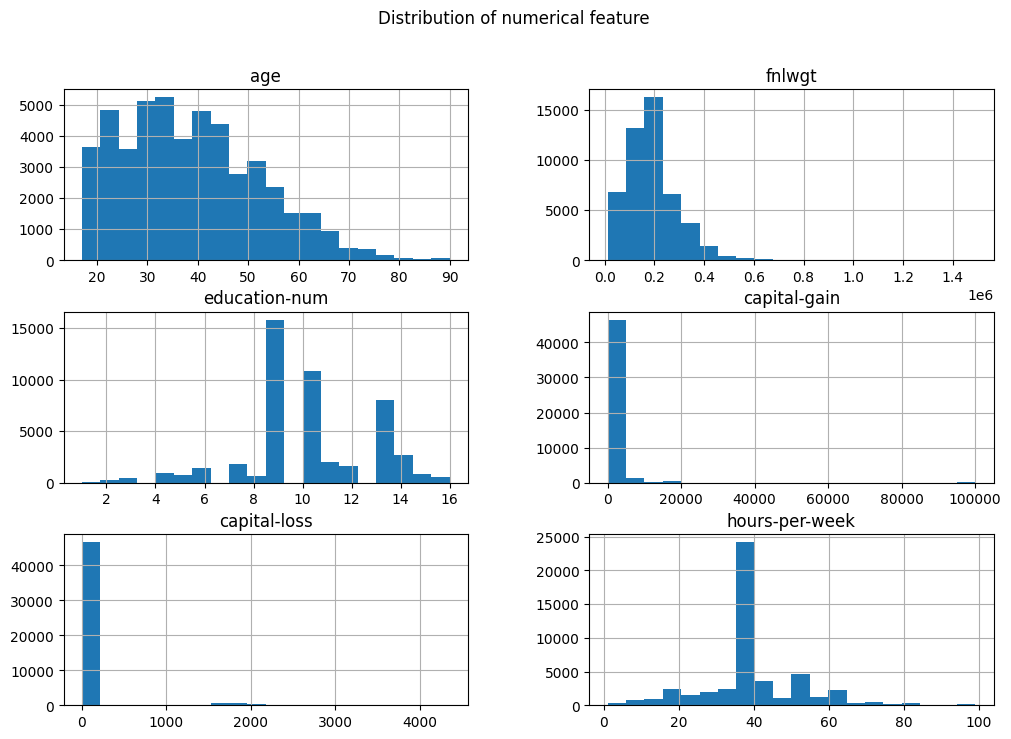

In [13]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of numerical feature")
plt.show()

# Age column a dekha jacche jader age (35-45) tader income >50k ,experiance barle income bartese

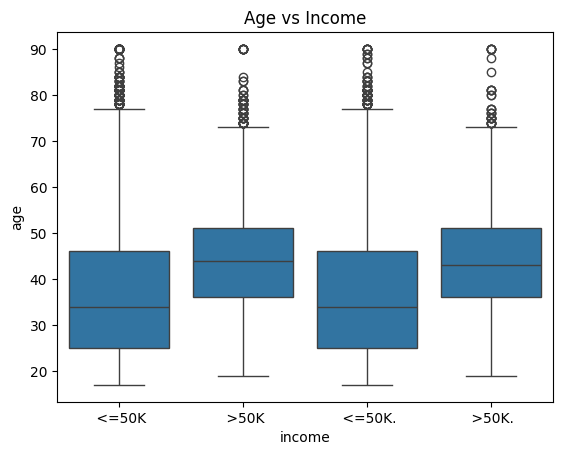

In [14]:
sns.boxplot(data=df, x="income", y="age")
plt.title("Age vs Income")
plt.show()

# akhane dekha jacche jader hours-per-week beshi tader income beshi

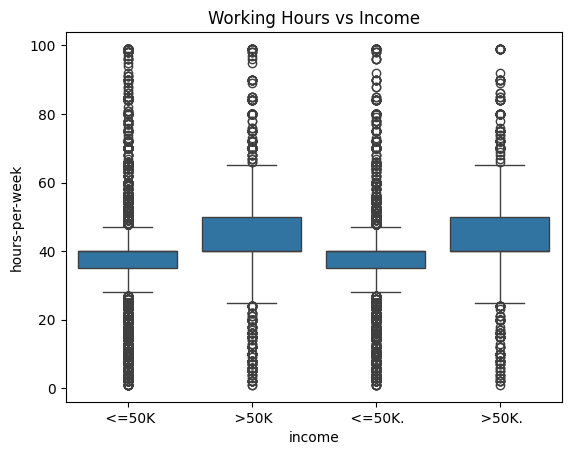

In [15]:
sns.boxplot(data=df, x="income", y="hours-per-week" )
plt.title("Working Hours vs Income")
plt.show()

# akhane dekha jacche jader higer education ase tader income ta >50k

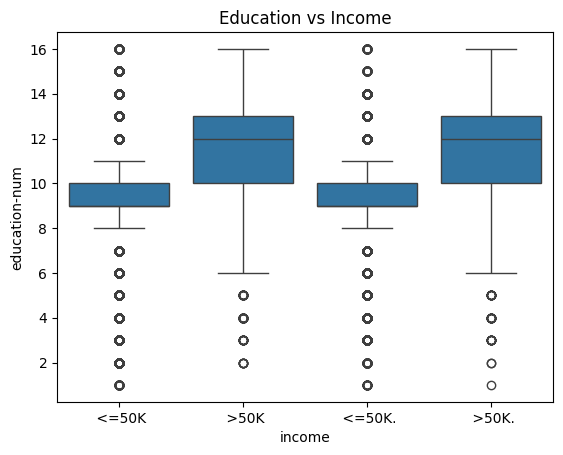

In [16]:
sns.boxplot(data=df, x="income", y="education-num" )
plt.title("Education vs Income")
plt.show()

In [17]:
df["income"] = df["income"].str.strip()
df["income"] = df["income"].replace({
    "<=50K.": "<=50K",
    ">50K.": ">50K"
})

In [18]:
le = LabelEncoder()

df["income"] = le.fit_transform(df["income"])



* Correlation metrics theke buja jay education-num  possitvly correlate ase income ar sathe.
* and age ar sathe o possitive correlate ase .
* and hours-per-week ar sathe o income ar possitive correlation ase

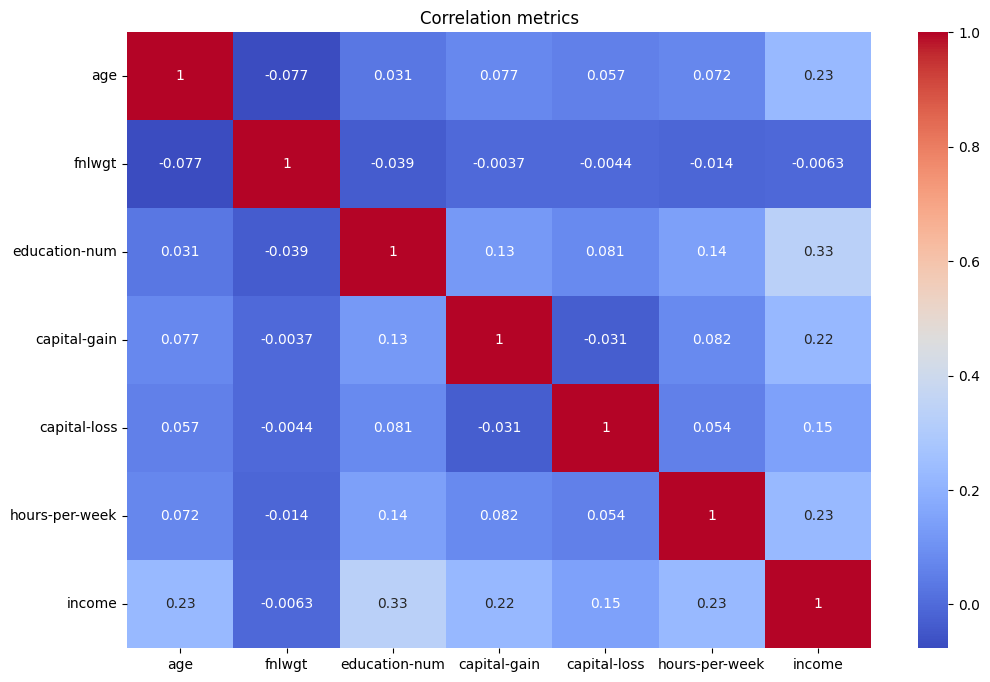

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap( df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation metrics")
plt.show()

In [20]:
corr = df.corr(numeric_only=True)["income"].sort_values(ascending=False)
corr.head(4)

,income
income,1.000000
education-num,0.332613
age,0.230369
hours-per-week,0.227687


# Question 2

In [21]:
X = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
#neumeric
neumeric_feature = X_train.select_dtypes(
    include=["int64","float64"]
).columns

#catagoric
catagorical_feature = X_train.select_dtypes(
    include=["object"]
).columns

### Numerical details
* simpleimputer diye missing value fill korbo
* Robustscaler use kore amra numerical feature ar outlier handle korbo

In [24]:
numeric_pipline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ("scaler", RobustScaler())
    ]
)
numeric_pipline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())])

### categorical details
* simpleimputer diye missing value fill korbo
* onehotencoder use kore amra categorical value ke encoding korbo

In [25]:
categorical_pipline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)
categorical_pipline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [26]:
preposessor= ColumnTransformer(
    transformers=[
        ('numeric_pipline', numeric_pipline, neumeric_feature),
        ('categorical_pipline',categorical_pipline,catagorical_feature),

    ],
    remainder='passthrough',

)

preposessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_pipline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'income'],
      dtype='object')),
                                ('categorical_pipline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])

## prepossesing details:-
*  first a columntransformer ar vitor data ashbe, ata jodi numerical data hoy tahole numerical pipline a dhukbe and jodi missing value thake tahole simpleimputer ar maddome impute hobe and standard scaller ar maddhome scalling kore sobaike akoi range a niye ashbe.And linear regression maddhome predict korbe.

* columntransformer a jodi kuno categorical value ashe tahole first a simpleimuter diye missing value impute korbe and pore onehotencoder diye categorical valu gulo encoding hobe and pore linear regression maddhome predict korbe.


In [27]:
hour_per_week_pipeline = Pipeline([

    ("preposessor", preposessor),
    ("model", LinearRegression())
])
hour_per_week_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preposessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'income'],
      dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [28]:
y_pred = hour_per_week_pipeline.predict(X_test)
y_pred

array([39.76470365, 30.56421958, 38.58029408, ..., 46.93134834,
       45.89923496, 45.21201586])

# Question 3

In [29]:
# SGD regressor
sgd_pipeline= Pipeline(
    steps = [
        ("preposesor",preposessor),
        ("model",SGDRegressor())
    ]
)

sgd_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preposesor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'income'],
      dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model', SGDRegressor())])

In [30]:
sgd_test = sgd_pipeline.predict(X_test)
sgd_test

array([-1.55967541e+10, -3.08951433e+09, -1.77822305e+10, ...,
       -2.87062531e+10, -4.56883117e+10, -4.34615221e+10])

In [31]:
# Evaluation
def evaluate(model,name):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  print(f"Name of the model: {name}")
  print("---"*40)

  #R2 score
  print("Train r2",round(r2_score(y_train,train_pred),4))
  print("test r2",round(r2_score(y_test,test_pred),4))

   # MSE
  print("MSE",round(np.sqrt(mean_squared_error(y_train,train_pred)),4))

  # MAE
  print("MAE",round(mean_absolute_error(y_test,test_pred),4))


  return(
      r2_score(y_test,test_pred),

      np.sqrt(mean_squared_error(y_test,test_pred)),

      mean_absolute_error(y_test,test_pred)
      )

## Model evluate:-


1.   Linear model ar R2score SGD model ar theke beshi tai ,akhane Linear model valo kortese SGD theke
2.   Linear model MSE  SGD Model ar MSE theke kom tai aikhane Linear model ar error kom
3.   Linear model MAE  SGD Model ar MAE theke kom tai aikhane Linear model SGD theke valo kortese
4.  Target col akhane akta continuse value tai aikhane Linear model valo korbe



In [32]:
# for Linear model
h_r2, h_mse, h_mae  = evaluate(hour_per_week_pipeline,"Linear Regrassion")

Name of the model: Linear Regrassion
------------------------------------------------------------------------------------------------------------------------
Train r2 0.1991
test r2 0.2015
MSE 11.0916
MAE 7.6573


In [33]:
# for SGD Model
s_r2, s_mse, s_mae = evaluate(sgd_pipeline,"SGD Regressor")

Name of the model: SGD Regressor
------------------------------------------------------------------------------------------------------------------------
Train r2 -6.36340060608001e+31
test r2 -5.961945034748098e+31
MSE 9.886418004120645e+16
MAE 1.3444891764590078e+16


# Question 4

In [34]:
X = df.drop('income', axis=1)
y = df['income']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
y_train

array([0, 0, 0, ..., 1, 0, 0])

In [37]:
#neumeric
lr_neumeric_feature = X_train.select_dtypes(
    include=["int64","float64"]
).columns

#catagoric
lr_catagorical_feature = X_train.select_dtypes(
    include=["object"]
).columns

In [38]:
lr_numeric_pipline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)
lr_numeric_pipline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [39]:
lr_categorical_pipline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
    ]
)
lr_categorical_pipline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [40]:
prepocessor= ColumnTransformer(
    transformers=[
        ('numeric_pipline', lr_numeric_pipline, lr_neumeric_feature),
        ('categorical_pipline',lr_categorical_pipline,lr_catagorical_feature),

    ],
    remainder='passthrough',

)

prepocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_pipline',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('categorical_pipline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])

In [41]:
lr_model = Pipeline(
    steps = [
        ('prepocessor', prepocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=10000))
    ]
)

lr_model.fit(X_train, y_train)

Pipeline(steps=[('prepocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=10000))])

In [42]:
pred_y = lr_model.predict(X_test)
pred_y

array([0, 0, 0, ..., 1, 0, 1])

In [43]:
accuracy = accuracy_score(y_test, pred_y)
print("accuracy",accuracy)
precision = precision_score(y_test, pred_y)
print("precision",precision)
recall = recall_score(y_test, pred_y)
print("Recall",recall)

accuracy 0.8077592384072064
precision 0.5671728971962616
Recall 0.8306244653550042


# Question 5

In [44]:
# KNN Model

Knn_model = Pipeline(
    steps=[
        ('prepocessor', prepocessor),

        ('knn', KNeighborsClassifier())
    ]
)
Knn_model

Pipeline(steps=[('prepocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical_pipline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('knn', KNeighborsClassifier())])

In [51]:
grid = {
    "knn__n_neighbors":range(1,20),
    "knn__weights":['uniform','distance'],
    "knn__p":[1,2]
     }

grid_Search = GridSearchCV(
    #KNN model
    estimator=Knn_model,
    param_grid=grid,
    cv=5
)
grid_Search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prepocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('numeric_pipline',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                                        ('categorical_pipline',
                                                                         Pipeline(steps=[...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': range(1, 20), 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']})

In [52]:
grid_Search.best_params_

{'knn__n_neighbors': 14, 'knn__p': 2, 'knn__weights': 'uniform'}

In [53]:
y_pred_knn = grid_Search.predict(X_test)

In [54]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)

print("KNN Accuracy :", acc_knn)
print("KNN Precision:", prec_knn)
print("KNN Recall   :", rec_knn)

KNN Accuracy : 0.8469648889343843
KNN Precision: 0.7284552845528456
KNN Recall   : 0.5748502994011976


In [55]:
two_model = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned KNN"],
    "Accuracy": [accuracy, acc_knn],
    "Precision": [precision, prec_knn],
    "Recall": [recall, rec_knn]
})

print(two_model)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.807759   0.567173  0.830624
1            Tuned KNN  0.846965   0.728455  0.574850
